## Import & Load Data

In [1]:

# scipy.stats for statistical tests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load cleaned HR data
df = pd.read_csv('../data/hr_cleaned.csv')
print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (1470, 36)


## Correlation Heatmap

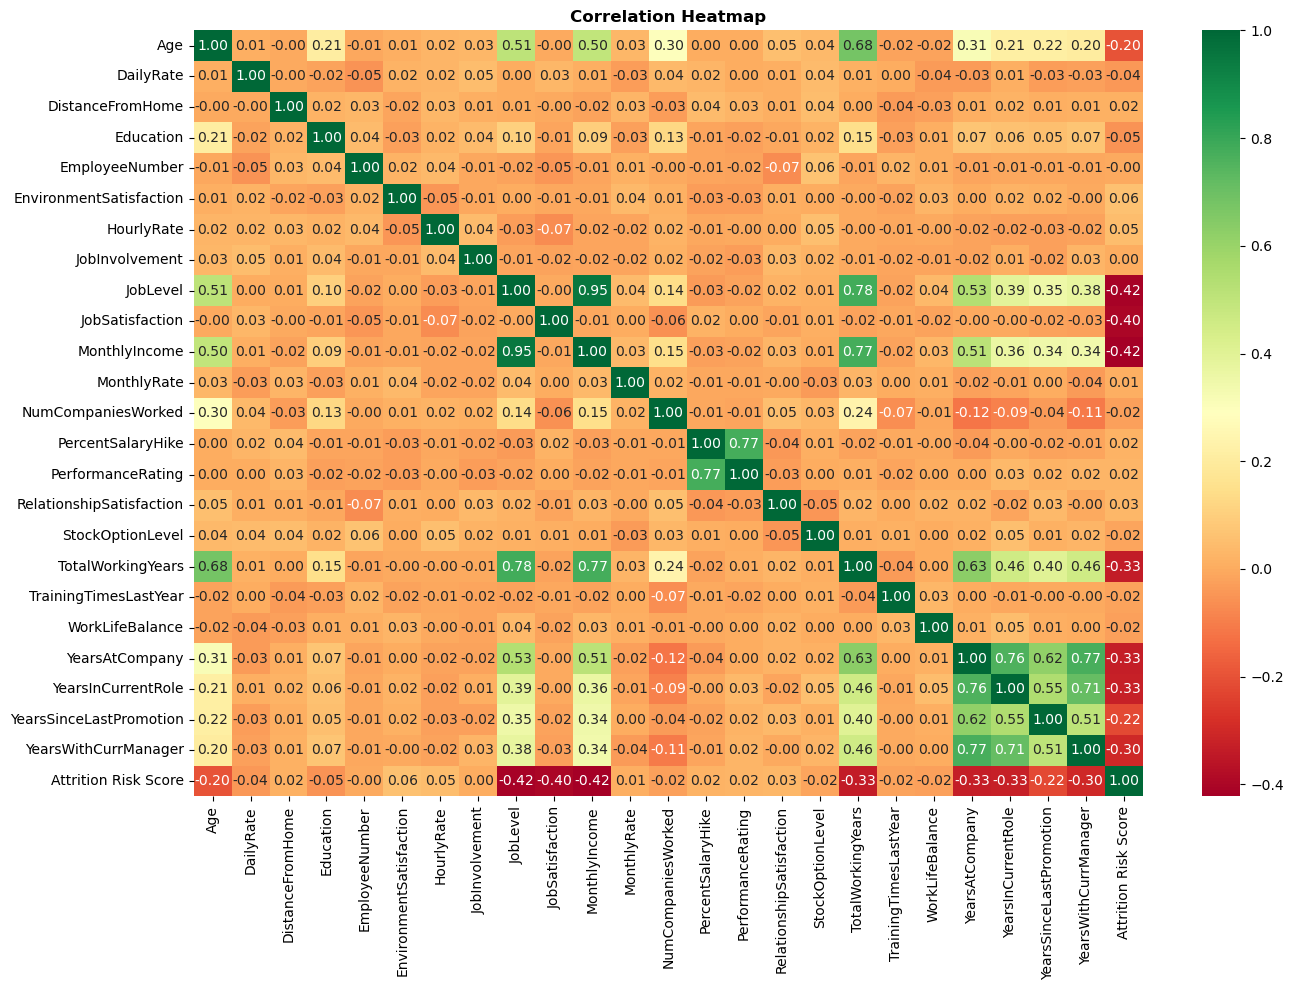

Heatmap saved!


In [2]:
# Correlation tells us how two columns are related
# Example: Does low salary cause attrition?
# Value close to 1  = strong positive relation
# Value close to -1 = strong negative relation
# Value close to 0  = no relation

# Select only number columns
# because correlation only works on numbers
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation between all columns
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr,
            annot=True,     # show numbers inside each box
            fmt='.2f',      # show 2 decimal places
            cmap='RdYlGn')  # red=negative green=positive
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

## Chi-Square Test (Overtime vs Attrition)

In [3]:
# Chi-Square test checks if overtime and attrition
# are related OR if it is just by coincidence
# Rule: if p-value < 0.05 = relationship is REAL
#       if p-value > 0.05 = relationship is by CHANCE

# Create a table: rows=Overtime, columns=Attrition
cross_tab = pd.crosstab(df['OverTime'], df['Attrition'])

# Run the chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab)

print("=" * 50)
print("TEST: Does Overtime cause Attrition?")
print("=" * 50)
print(f"P-Value: {round(p_value, 4)}")

# Interpret the result in simple words
if p_value < 0.05:
    print("✅ YES — Overtime SIGNIFICANTLY causes Attrition!")
else:
    print("❌ NO — No strong relationship found")

TEST: Does Overtime cause Attrition?
P-Value: 0.0
✅ YES — Overtime SIGNIFICANTLY causes Attrition!


##  Salary Distribution Chart

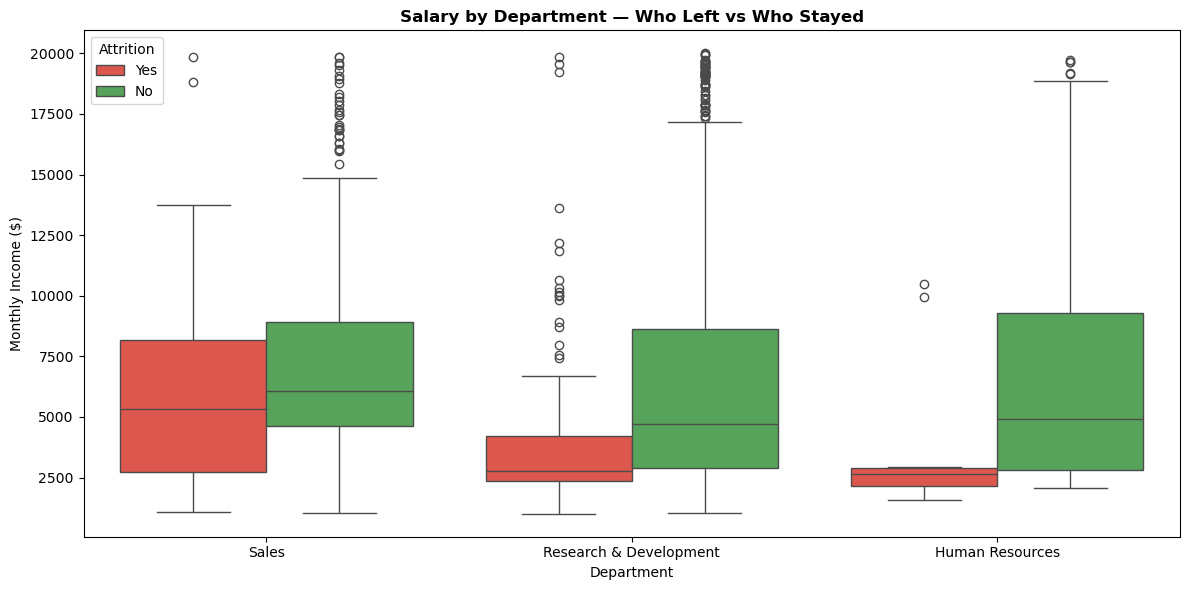

Chart saved!


In [4]:
# Box plot shows salary range for each department
# Split by Attrition Yes/No
# This helps us see if low salary causes attrition

plt.figure(figsize=(12, 6))
sns.boxplot(x='Department',      # x axis = departments
            y='MonthlyIncome',   # y axis = salary
            hue='Attrition',     # split by who left vs stayed
            data=df,
            palette={'Yes': '#F44336',  # red = left
                     'No': '#4CAF50'})  # green = stayed

plt.title('Salary by Department — Who Left vs Who Stayed',
          fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.savefig('../outputs/03_salary_distribution.png', dpi=150)
plt.show()
print("Chart saved!")


## Attrition Risk Score Validation

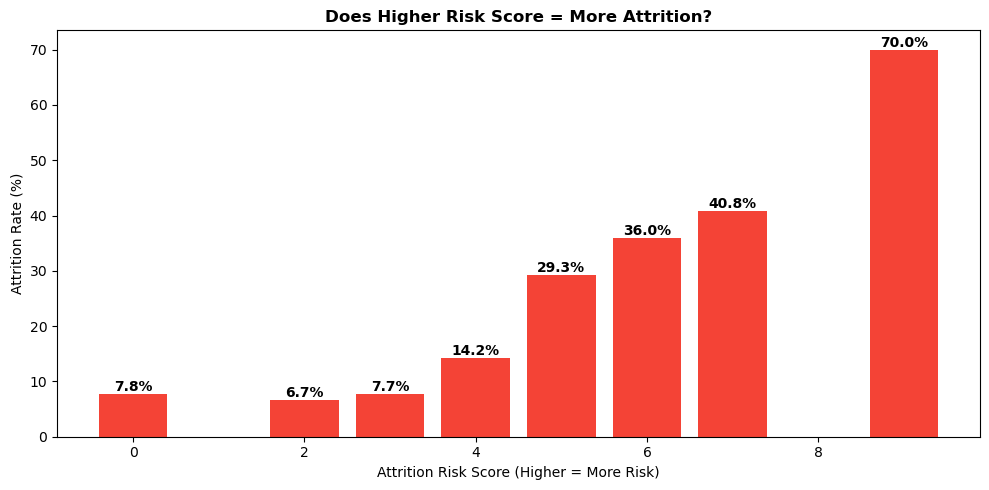

RISK SCORE SUMMARY
Avg Risk Score — Employees Who LEFT  : 4.75
Avg Risk Score — Employees Who STAYED: 2.96

✅ Risk Score works! Higher score = more attrition!


In [5]:
# Here we check if our Attrition Risk Score
# actually works correctly
# Higher score should mean = more attrition

# Calculate attrition % for each risk score level
risk_attr = df.groupby('Attrition Risk Score')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
risk_attr.columns = ['Risk Score', 'Attrition Rate %']

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(risk_attr['Risk Score'],
        risk_attr['Attrition Rate %'],
        color='#F44336')
plt.title('Does Higher Risk Score = More Attrition?',
          fontweight='bold')
plt.xlabel('Attrition Risk Score (Higher = More Risk)')
plt.ylabel('Attrition Rate (%)')

# Add % label on top of each bar
for i, row in risk_attr.iterrows():
    plt.text(row['Risk Score'],
             row['Attrition Rate %'] + 0.5,
             f"{row['Attrition Rate %']:.1f}%",
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_risk_score_validation.png', dpi=150)
plt.show()

# Final conclusion
avg_left  = round(df[df['Attrition']=='Yes']['Attrition Risk Score'].mean(), 2)
avg_stay  = round(df[df['Attrition']=='No']['Attrition Risk Score'].mean(), 2)

print("=" * 50)
print("RISK SCORE SUMMARY")
print("=" * 50)
print(f"Avg Risk Score — Employees Who LEFT  : {avg_left}")
print(f"Avg Risk Score — Employees Who STAYED: {avg_stay}")

if avg_left > avg_stay:
    print("\n✅ Risk Score works! Higher score = more attrition!")
else:
    print("\n❌ Risk Score needs improvement")